**Advanced Machine Learning (Semester 2 2025)**
# 5 Convolutional Neural Networks


*N. Hernitschek, 2025*


This Jupyter notebook gives an intro to Convolutional Neural Networks.
Also, here we use a professional neural network library.



---
## Contents
* [Our own CNN code](#first-bullet)
* [Using professional neural network libraries: MNIST with Keras visualization](#second-bullet)
* [Preparation for next time](#third-bullet)
* [Summary](#fourth-bullet)

## 1. Our own CNN code<a class="anchor" id="first-bullet"></a>


To better understand the internals of a CNN, we here start with creating our own CNN code.
It is not as fast and comfortable as using a professional neural network library (such as keras/tensorflow), but it allows for more easily understanding and manipulating the internals of a CNN.




In [1]:
### Convolution Layers


import numpy as np

# ReLU, Softmax, and Loss functions:

import numpy as np

def relu(x):
  if x < 0:
    return 0
  else:
    return x

def softmax(x):
  return np.exp(x) / np.sum(np.exp(x))

def loss(y_pred):
  return -np.log(y_pred)


class Convolution2D:
  def __init__(self, k1, b1, stride=1, padding=0):
    """
      - k1: (6, 5, 5) kernels
      - b1: (6) bias
    """
    self.k1 = k1
    self.b1 = b1
    self.stride = stride
    self.padding = padding

  def feedforward(self, img):
    """
      - img: (28, 28) image
    """

    N, k1_height, _ =  self.k1.shape
    stride = self.stride

    C1_height = int((img.shape[0] - k1_height + 2 * self.padding) / self.stride) + 1

    # Initialize C
    C1 = np.zeros((N, C1_height, C1_height), dtype=np.float64)
    dC1S1 = np.zeros(C1.shape, dtype=np.float64)

    for n in range(N):
      for i in range(C1_height):
        for j in range(C1_height):
          region = img[i+stride-1:(i+stride-1 + k1_height), j+stride-1:(j+stride-1 + k1_height)]
          S1_nij = np.sum(region * self.k1[n]) + self.b1[n]
          C1[n, i, j] = relu(S1_nij)
          dC1S1[n, i, j] = 1 if S1_nij > 0 else 0

    return C1, dC1S1


class Convolution3D:
  def __init__(self, k2, b2, stride=1, padding=0):
    """
      - k2:   (12, 6, 5, 5) kernels
      - b2:   (12) bias
    """
    self.k2 = k2
    self.b2 = b2
    self.stride = stride
    self.padding = padding

  def feedforward(self, P1):
    """
      - P1: (6, 12, 12) image
    """
    M, N, k2_height, _ = self.k2.shape
    C2_height = int((P1.shape[1] - k2_height + 2 * self.padding) / self.stride) + 1

    C2 = np.zeros((M, C2_height, C2_height), dtype=np.float64)
    dC2S2 = np.zeros(C2.shape, dtype=np.float64)
    dS2P1 = np.zeros(P1.shape + C2.shape, dtype=np.float64)

    for m in range(M):
      for u in range(C2_height):
        for v in range(C2_height):
          region = P1[0:N, u+self.stride-1:(u+self.stride-1 + k2_height), v+self.stride-1:(v+self.stride-1 + k2_height)]
          S2_muv = np.sum(region * self.k2[m]) + self.b2[m]
          C2[m, u, v] = relu(S2_muv)
          dC2S2[m, u, v] = 1 if S2_muv > 0 else 0
          dS2P1[0:N, u:(u + k2_height), v:(v + k2_height), m, u, v] = self.k2[m]

    return C2, dC2S2, dS2P1


In [2]:
# Pooling layers


import numpy as np

class MaxPool:
  def __init__(self, size=2):
    self.size = size

  def feedforward(self, C):
    N, C_height, _ = C.shape
    P_height = int(C_height / self.size)

    P = np.zeros((N, P_height, P_height), dtype=np.float64)
    indices = np.zeros((N, P_height, P_height), dtype=(np.int64, 2))

    for n in range(N):
      for i in range(P_height):
        for j in range(P_height):
          #region = C[n, (2 * i):(2 * i + 2), (2 * j):(2 * j + 2)]
          region = C[n, (self.size * i):(self.size * i + self.size), (self.size * j):(self.size * j + self.size)]
          P[n, i, j] = np.max(region)
          local_indices = np.unravel_index(np.argmax(region), region.shape)
          indices[n, i, j] = [2 * i + local_indices[0], 2 * j + local_indices[1]]

    return P, indices


For the following, we will use MNIST.

The MNIST database is a dataset of hand-written digits. It has 60,000 training samples, and 10,000 test samples. Each image is represented by 28 $\times$ 28 pixels, each containing a value 0 to 255 which is a grayscale value.

We access it through the `mnist` package which we need to install:


In [ ]:
pip install mnist

To automatically download the training files, and display the first image in the dataset, you can simply use:

In [4]:
import mnist
import scipy.misc


mnist.datasets_url = 'https://ossci-datasets.s3.amazonaws.com/mnist/'

images = mnist.train_images()

#print(images)


We can plot some example images. For this, we install the package `pillow`and then write:

In [5]:
from PIL import Image

pil_image_1 = Image.fromarray(images[0,:,:])
pil_image_1

In [6]:

pil_image_2 = Image.fromarray(images[1,:,:])
pil_image_2

In the following, we create a CNN to recognize these hand-written numbers:

In [7]:
# CNN (including Feedforward and Backpropagation)


# this is where all the derivations come from:
# https://medium.com/@ngocson2vn/a-gentle-explanation-of-backpropagation-in-convolutional-neural-network-cnn-1a70abff508b
# --> a clear case where one has to make all the derivations before on paper to write the code...

import math
import numpy as np

class CNN:
  def __init__(self, N, M):
    u1 = 0.1
    u2 = 0.1
    u = 0.1
    self.k1 = np.random.uniform(low=-u1, high=u1, size=(N, 5, 5))
    self.b1 = np.random.uniform(low=-u1, high=u1, size=(N))
    self.k2 = np.random.uniform(low=-u2, high=u2, size=(M, N, 5, 5))
    self.b2 = np.random.uniform(low=-u2, high=u2, size=(M))
    self.w = np.random.uniform(low=-u, high=u, size=(10, M * 16))
    self.b = np.random.uniform(low=-u, high=u, size=(10))


  def feedforward(self, img):
    ## Convolution Layer C1
    conv1 = Convolution2D(self.k1, self.b1, stride=1, padding=0)
    C1, dC1S1 = conv1.feedforward(img)

    ## Pooling Layer P1
    maxpool = MaxPool(size=2)
    P1, I1 = maxpool.feedforward(C1)

    ## Convolution Layer C2
    conv2 = Convolution3D(self.k2, self.b2, stride=1, padding=0)
    C2, dC2S2, dS2P1 = conv2.feedforward(P1)

    ## Pooling Layer P2
    P2, I2 = maxpool.feedforward(C2)

    ## FC Layer
    f = P2.flatten()
    O = softmax(np.dot(self.w, f) + self.b)

    return O


  def train(self, train_images, train_labels, test_images, test_labels, epoch, lr):
    N = self.k1.shape[0]
    M = self.k2.shape[0]
    epochs = []
    avg_losses = []
    accuracies = []

    for ep in range(epoch):
      # Shuffle the training data
      permutation = np.random.permutation(len(train_images))
      train_images = train_images[permutation]
      train_labels = train_labels[permutation]
      for img, label in zip(train_images, train_labels):

        ############################################################
        # Feedforward phase                                        #
        ############################################################

        ## Convolution Layer C1
        conv1 = Convolution2D(self.k1, self.b1, stride=1, padding=0)
        C1, dC1S1 = conv1.feedforward(img)

        ## Pooling Layer P1
        maxpool = MaxPool(size=2)
        P1, I1 = maxpool.feedforward(C1)

        ## Convolution Layer C2
        conv2 = Convolution3D(self.k2, self.b2, stride=1, padding=0)
        C2, dC2S2, dS2P1 = conv2.feedforward(P1)
        
        #print('N')
        #print(N)
        
        #print ('shape of dS2P1')
        #print(dS2P1.shape)
        #(6, 12, 12, 12, 8, 8)

        ## Pooling Layer P2
        P2, I2 = maxpool.feedforward(C2)

        ## FC Layer
        f = P2.flatten()
        O = softmax(np.dot(self.w, f) + self.b)


        ############################################################
        # Backpropagation phase                                    #
        ############################################################

        ## 1. Calculate gradients of parameters in the FC layer
        dLS = np.copy(O)
        dLS[label] = O[label] - 1
        dLb = np.copy(dLS)
        #print('label')
        #print(label)
        #print('dLS')
        #print(dLS)
        #print('O')
        #print(O)
        
        
        # dLS is the derivative of the loss function w.r.t. to S
        # as a loss function, cross-entropy is used, leading to the derivative
        # the loss function is a function of the output at the given label
        # -log(prediction)
        
        dLw = np.zeros(O.shape + f.shape, dtype=np.float64)
        for i in range(O.shape[0]):
          dLw[i, :] = O[i] * f
        dLw[label, :] = (O[label] - 1) * f

        dLf = np.zeros(f.shape, dtype=np.float64)
        for j in range(f.shape[0]):
          dLf[j] = np.sum(dLS * self.w[:, j])

        dLP2 = dLf.reshape(P2.shape)

        ## 2. Calculate gradients of parameters in the C2 layer

        ### 2.1. Calculate dLC2
        dLC2 = np.zeros(C2.shape, dtype=np.float64)

        for m in range(P2.shape[0]):
           for x in range(P2.shape[1]):
             for y in range(P2.shape[2]):
               umax, vmax = I2[m, x, y]
               dLC2[m, umax, vmax] = dLP2[m, x, y]

        ### 2.2. Calculate dLS2
        dLS2 = dLC2 * dC2S2

        ### 2.3. Calculate dLb2 and dLk2
        dLb2 = np.zeros(self.k2.shape[0], dtype=np.float64)
        dLk2 = np.zeros(self.k2.shape, dtype=np.float64)
        for m in range(self.k2.shape[0]):
          dLb2[m] = np.sum(dLS2[m])
          for n in range(self.k2.shape[1]):
            for p in range(self.k2.shape[2]):
              for q in range(self.k2.shape[3]):
                dLk2[m, n, p, q] = np.sum(dLS2[m] * P1[n][p:(p + C2.shape[1]), q:(q + C2.shape[2])])

        

        ## 3. Calculate gradients of parameters in the C1 layer

        ### 3.1. Calculate dLP1
        dLP1 = np.zeros(P1.shape, dtype=np.float64)
        for n in range(P1.shape[0]):
          for r in range(P1.shape[1]):
            for s in range(P1.shape[2]):
              dLP1[n, r, s] = np.sum(dLS2 * dS2P1[n, r, s])


        ### 3.2. Calculate dLC1
        dLC1 = np.zeros(C1.shape, dtype=np.float64)
        for n in range(P1.shape[0]):
           for r in range(P1.shape[1]):
             for s in range(P1.shape[2]):
               imax, jmax = I1[n, r, s]
               dLC1[n, imax, jmax] = dLP1[n, r, s]

        ### 3.3. Calculate dLS1
        dLS1 = dLC1 * dC1S1

        ### 3.4. Calculate dLb1 and dLk1
        dLb1 = np.zeros(self.k1.shape[0], dtype=np.float64)
        dLk1 = np.zeros(self.k1.shape, dtype=np.float64)
        for n in range(self.k1.shape[0]):
          dLb1[n] = np.sum(dLS1[n])
          for g in range(self.k1.shape[1]):
            for h in range(self.k1.shape[2]):
              dLk1[n, g, h] = np.sum(dLS1[n] * img[g:(g + C1.shape[1]), h:(h + C1.shape[2])])


        ## 4. Update parameters
        self.k1 = self.k1 - lr * dLk1
        self.b1 = self.b1 - lr * dLb1

        self.k2 = self.k2 - lr * dLk2
        self.b2 = self.b2 - lr * dLb2

        self.w  = self.w  - lr * dLw
        self.b  = self.b  - lr * dLb


      losses = []
      acc = 0
      for img, label in zip(test_images, test_labels):
        O = self.feedforward(img)
        losses.append(-np.log(O[label]))
        acc += 1 if np.argmax(O) == label else 0
      losses = np.array(losses)
      
      epochs.append(ep + 1)
      avg_losses.append(losses.mean())
      accuracy = 100 * acc / len(test_labels)
      accuracies.append(accuracy)
      print("Epoch: {}, validate_average_loss: {}, validate_accuracy: {:02.2f}%".format(ep + 1, losses.mean(), accuracy))

    return (epochs, avg_losses, accuracies)

We now train our CNN. 

**Caution:** This implementation is pretty slow. Training the CNN can take 1 hour or more.
I suggest to **not** start this now...
Rather, for plotting, we use the saved (pickled) `model_saved.bin`.

A **general advice**: Training a CNN, like training any other kind of machine learning algorithm, takes longer than applying it. Thus after successful training, one should always save the trained model. This will not only ensure reasonable execution speed for applying the model, but also ensure that each time the model is applied to data indeed the same model is used.

In [ ]:
# Training the Convolutional Neural Network

import mnist
import numpy as np
#from cnn import CNN
import matplotlib.pyplot as plt
import pickle

np.set_printoptions(edgeitems=100, linewidth=200000)

cnn = CNN(6, 12)

train_images = (mnist.train_images() / 255) - 0.5
train_labels = mnist.train_labels()

test_images = (mnist.test_images() / 255) - 0.5
test_labels = mnist.test_labels()

stats = cnn.train(train_images[:10000], train_labels[:10000], test_images[:1000], test_labels[:1000], 10, 0.005)
epochs = stats[0]
avg_losses = stats[1]
accuracies = stats[2]

with open("model.bin", "wb") as f:
  pickle.dump(cnn, f)

fig = plt.figure()
plt.subplots_adjust(hspace=0.5)

g1 = fig.add_subplot(2, 1, 1, ylabel="Loss", xlabel="Epoch")
g1.plot(epochs, avg_losses, label="Avg loss", color="red")
g1.legend(loc="center")

g2 = fig.add_subplot(2, 1, 2, ylabel="Accuracy", xlabel="Epoch")
g2.plot(epochs, accuracies, label="Accuracy", color="green")
g2.legend(loc="center")

plt.show()

We train the Convolutional Neural Network with 10,000 training images and learning rate = 0.005. After each epoch, we evaluate the network against 1000 test images. After 10 epochs, we got the the result as shown above.

**Suggestion:** You can try to modify e.g. the size of the training set. What happens?

We are now using the trained Convolutional Neural Network to infer handwritten digits.

As I've included the pickled model in `model_saved.bin`, you can immediately execute this code without training first.

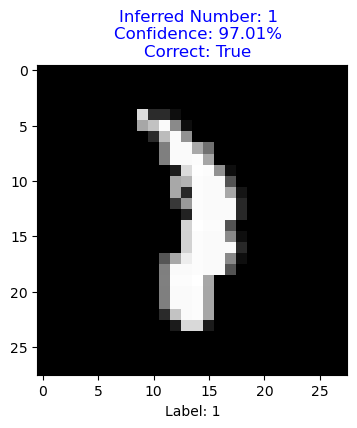

In [8]:

import mnist
import numpy as np
import argparse

import matplotlib.pyplot as plt
from termcolor import colored
import pickle

#parser = argparse.ArgumentParser()
#parser.add_argument("-i", "--index", help="The index of a test image.", type=int, required=True)
#index = int(vars(parser.parse_args())["index"])

index = 2018

test_images = (mnist.test_images() / 255) - 0.5
test_labels = mnist.test_labels()
img = test_images[index]
label = test_labels[index]

with open("model_saved.bin", "rb") as model:
  cnn = pickle.load(model)

fig = plt.figure(figsize=(4, 5))

O = cnn.feedforward(img)
inference = np.argmax(O)
confidence = O[label] * 100 # the confidence of it being from the right class
# could also define: the confidence of being from the class the classifier sees as most likely
correct = "True" if inference == label else "False"
cmap = plt.get_cmap("gray") if inference == label else plt.get_cmap("Reds")
color = "blue" if inference == label else "red"

title = "Inferred Number: {}\nConfidence: {:02.2f}%\nCorrect: {}".format(inference, confidence, correct)
sub = fig.add_subplot(1, 1, 1, xlabel="Label: {}".format(label))
sub.text(14, -1, title, ha="center", va="bottom", size="large", color=color)
sub.imshow(img, cmap=cmap)

plt.show()



## 2. MNIST with Keras Visualization<a class="anchor" id="second-bullet"></a>

(adapted from https://www.kaggle.com/code/ernie55ernie/mnist-with-keras-visualization-and-saliency-map)
    


This notebook contains the basic usage of keras and sklearn on the MNIST data set.
The four steps are:

1. Stratified shuffling split on training data set
2. Training and validating a CNN
3. plotting a confusion matrix
4. visualizing the convolution filters


There are 2 outputs

 *   Prediction csv on testing data
 *   Keras model


Before starting the code, download the files `test.csv` and `train.csv` from the above website.

In [9]:
%matplotlib inline
import numpy as np 
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
# read input csv file
train_df = pd.read_csv('input_notebook5/mnist_train.csv')
test_df = pd.read_csv('input_notebook5/mnist_test.csv')


In [11]:
X_train = []
Y_train = []
X_test = []

# reshape training data from rows into images
for index, row in train_df.iterrows():
    X_train.append(row.values[1 : ].reshape((28, 28, 1)))
    Y_train.append(row['label'])

# reshape testing data from rows into images
for index, row in test_df.iterrows():
    X_test.append(row.values.reshape((28, 28, 1)))

# normalization
X_train = np.array(X_train) / 255.
Y_train = np.array(Y_train)
X_test = np.array(X_test) / 255.

print('There are', X_train.shape[0], 'training data and', X_test.shape[0], 'testing data')
print('Number of occurence for each number in training data (0 stands for 10):')
print(np.vstack((np.unique(Y_train), np.bincount(Y_train))).T)


There are 42000 training data and 28000 testing data
Number of occurence for each number in training data (0 stands for 10):
[[   0 4132]
 [   1 4684]
 [   2 4177]
 [   3 4351]
 [   4 4072]
 [   5 3795]
 [   6 4137]
 [   7 4401]
 [   8 4063]
 [   9 4188]]


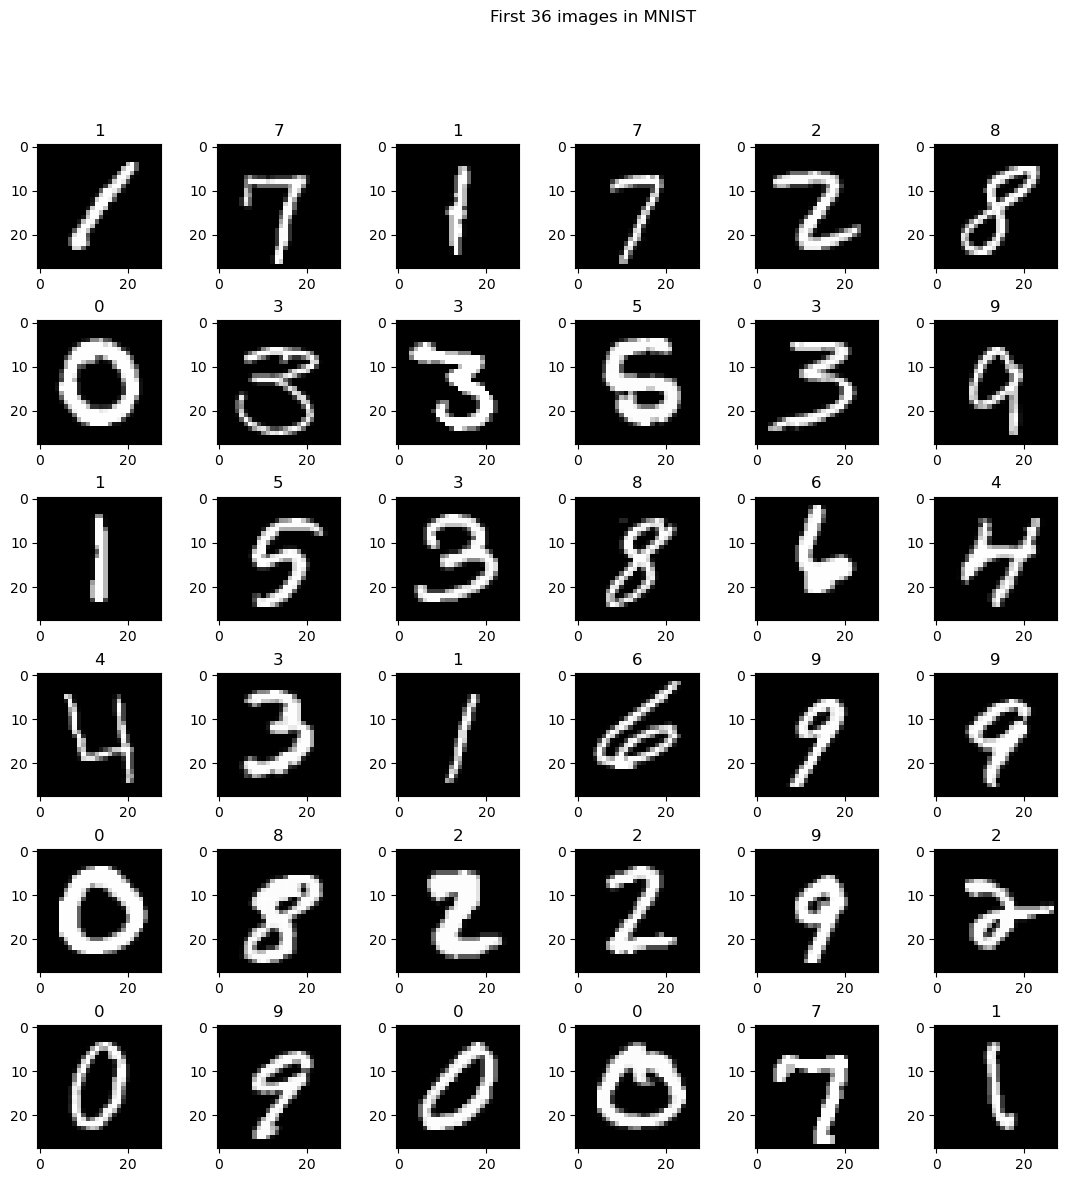

In [12]:
# plot first 36 images in MNIST
fig, ax = plt.subplots(6, 6, figsize = (12, 12))
fig.suptitle('First 36 images in MNIST')
fig.tight_layout(pad = 0.3, rect = [0, 0, 0.9, 0.9])
for x, y in [(i, j) for i in range(6) for j in range(6)]:
    ax[x, y].imshow(X_train[x + y * 6].reshape((28, 28)), cmap = 'gray')
    ax[x, y].set_title(Y_train[x + y * 6])

In [13]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn import preprocessing

# transform training label to one-hot encoding
lb = preprocessing.LabelBinarizer()
lb.fit(Y_train)
Y_train = lb.transform(Y_train)

# split training and validating data
print('Stratified shuffling...')
sss = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state = 15)
for train_idx, val_idx in sss.split(X_train, Y_train):
    X_train_tmp, X_val = X_train[train_idx], X_train[val_idx]
    Y_train_tmp, Y_val = Y_train[train_idx], Y_train[val_idx]

X_train = X_train_tmp
Y_train = Y_train_tmp
print('Finish stratified shuffling...')

Stratified shuffling...
Finish stratified shuffling...


You might need to install keras and tensorflow.


**Caution:** In case you encounter errors, often incompatibility of the certain libraries is the reason for that.
I suggest googling for that, and a combination of libraries that usually works can be installed like


`pip install tensorflow==2.12.0`


`pip install numpy==1.23`

I suggest after installing the libraries accordingly, try an import at the terminal window, and if `import keras`is sucessful: restart the Jupyter kernel and try whether it works in the Jupyter notebook.


In [16]:
import keras
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D
#from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator


img_size = (28, 28, 1)
n_classes = 10

if os.path.exists('keras_model.keras'):
    print('Loading model...')
    model = load_model('keras_model.keras')
else:
    print('Building model...')
    model = Sequential()
    model.add(Conv2D(32, (5, 5), input_shape = img_size, kernel_initializer = 'normal'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(Conv2D(64, (5, 5), kernel_initializer = 'normal'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(128))
    model.add(Activation('relu'))
    model.add(Dropout(0.5))
    model.add(Dense(n_classes))
    model.add(Activation('softmax'))

    model.compile(loss = 'categorical_crossentropy', optimizer = 'rmsprop', metrics = ['accuracy'])

Building model...


/home/nhernits/.local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# data augmentation
datagen = ImageDataGenerator(
    featurewise_center = False,
    samplewise_center = False,
    featurewise_std_normalization = False,
    samplewise_std_normalization = False,
    zca_whitening = False,
    rotation_range = 0,
    zoom_range = 0.1,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = False,
    vertical_flip = False
)

datagen.fit(X_train)

In contrast to our own CNN code from section 1, this runs ways faster. You can safely execute this now; it should take about 15 minutes.

In [24]:
print('Training model...')

model.fit(datagen.flow(X_train, Y_train, batch_size = 1000),
                   epochs = 20,
                   validation_data = (X_val, Y_val),
                   steps_per_epoch = int(X_train.shape[0] / 1000),
                   verbose = 1)

print('Validating model...')
score, acc = model.evaluate(X_val, Y_val, verbose = 1)
print('\nLoss:', score, '\nAcc:', acc)
model.save('keras_model.keras')

Training model...
Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 623ms/step - accuracy: 0.9575 - loss: 0.1392 - val_accuracy: 0.9833 - val_loss: 0.0537
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9520 - loss: 0.1654 - val_accuracy: 0.9833 - val_loss: 0.0571
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 626ms/step - accuracy: 0.9640 - loss: 0.1202 - val_accuracy: 0.9863 - val_loss: 0.0467
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9730 - loss: 0.1094 - val_accuracy: 0.9851 - val_loss: 0.0476
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 592ms/step - accuracy: 0.9604 - loss: 0.1260 - val_accuracy: 0.9854 - val_loss: 0.0499
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9650 - loss: 0.1138 - val_accuracy: 0.9862 - val_loss: 0.0437
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 661ms/step - accuracy: 0.9667 - loss: 0.1075 - val_accuracy: 0.9870 - val_loss: 0.0430
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.9790 - loss: 0.0724 

In [25]:
print('Predicting...')
Y_test = model.predict(X_test)
Y_test = lb.inverse_transform(Y_test)
Y_test = [[y] for y in Y_test]
index = [[i] for i in range(1, X_test.shape[0] + 1)]
output_np = np.concatenate((index, Y_test), axis = 1)
output_df = pd.DataFrame(data = output_np, columns = ['ImageId', 'Label'])
output_df.to_csv('out.csv', index = False)

Predicting...
875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step 


Text(0.5, 21.34715460257995, 'Predicted label')

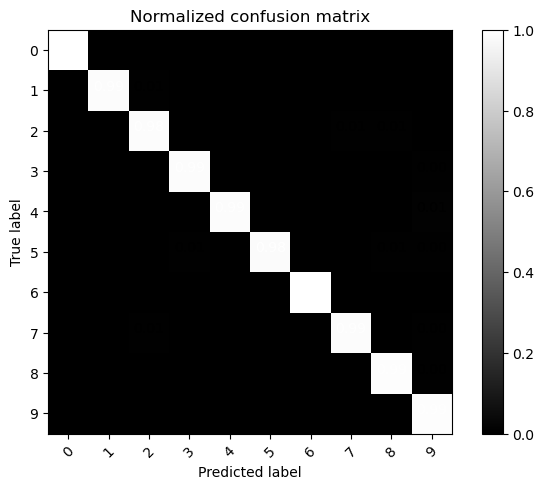

In [26]:
from sklearn.metrics import confusion_matrix
import itertools

Y_pred = model.predict(X_val)
Y_val_pred = lb.inverse_transform(Y_pred)
Y_val_real = lb.inverse_transform(Y_val)
cm = confusion_matrix(Y_val_real, Y_val_pred)
cm = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis]

# print(cm)
plt.imshow(cm, cmap = 'gray')
plt.title('Normalized confusion matrix')
plt.colorbar()
tick_marks = np.arange(n_classes)
plt.xticks(tick_marks, np.arange(n_classes), rotation=45)
plt.yticks(tick_marks, np.arange(n_classes))

fmt = '.2f'
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')

The confusion matrix looks great!  In case you don't remember its purpose, look it up.

We can get some more information from the CNN:

In [34]:
# Visualizating filters
import tensorflow.keras.backend as K
import tensorflow as tf
tf.compat.v1.disable_eager_execution()

K.set_image_data_format('channels_first')
model = load_model('keras_model.keras')

layer_dict = dict([(layer.name, layer) for layer in model.layers])
#print('Layer dict', layer_dict)
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369,174 (1.41 MB)

 Trainable params: 184,586 (721.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 184,588 (721.05 KB)

None


## 3. Preparation for next time<a class="anchor" id="third-bullet"></a>

As you will start with thinking about your project idea, you can now think regarding data and algorithms that will help you to implement your idea.

As always: Looking up work by others, such as documentation and papers, isn't a bad thing! Just cite it properly.


## 4. Summary <a class="anchor" id="fourth-bullet"></a>

At this point, all of you should have:
* a running keras/tensorflow installation
* first experience with building a neural network with keras/tensorflow and how to visualize it




